In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/energy_clean.csv")

In [3]:
df["time"] = pd.to_datetime(df["time"], utc=True)     # converts time into datetime format so time-based analysis works properly.

In [4]:
df = df.sort_values("time").reset_index(drop=True)    # keeps observations in chronological order for correct time-series analysis.

In [5]:
print(df.shape)

(35028, 3)


In [6]:
print(df.head())

                       time     load  price
0 2014-12-31 23:00:00+00:00  25385.0  50.10
1 2015-01-01 00:00:00+00:00  24382.0  48.10
2 2015-01-01 01:00:00+00:00  22734.0  47.33
3 2015-01-01 02:00:00+00:00  21286.0  42.27
4 2015-01-01 03:00:00+00:00  20264.0  38.41


In [7]:
print(df[["load", "price"]].describe())

               load         price
count  35028.000000  35028.000000
mean   28696.939905     49.870741
std     4574.987950     14.618777
min    18041.000000      2.060000
25%    24807.750000     41.490000
50%    28901.000000     50.520000
75%    32192.000000     60.530000
max    41015.000000    101.990000


In [8]:
print("Start date:", df["time"].min())
print("End date:", df["time"].max())

Start date: 2014-12-31 23:00:00+00:00
End date: 2018-12-31 22:00:00+00:00


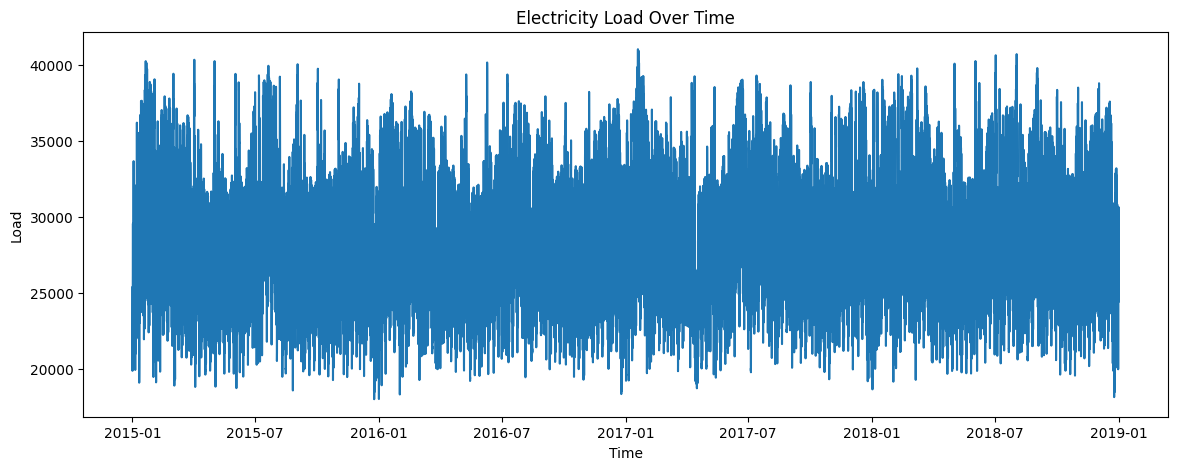

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df["time"], df["load"])
plt.title("Electricity Load Over Time")
plt.xlabel("Time")
plt.ylabel("Load")
plt.show()

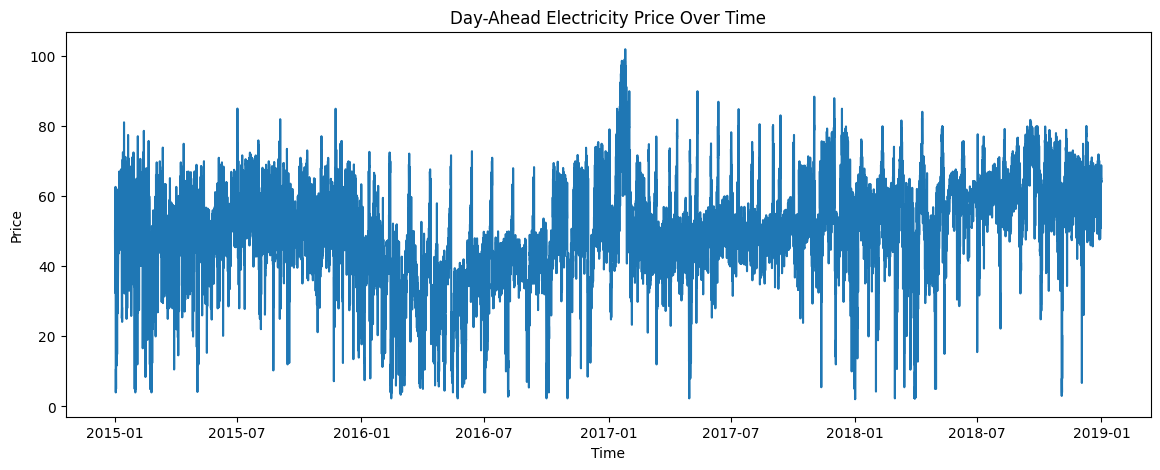

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(df["time"], df["price"])
plt.title("Day-Ahead Electricity Price Over Time")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

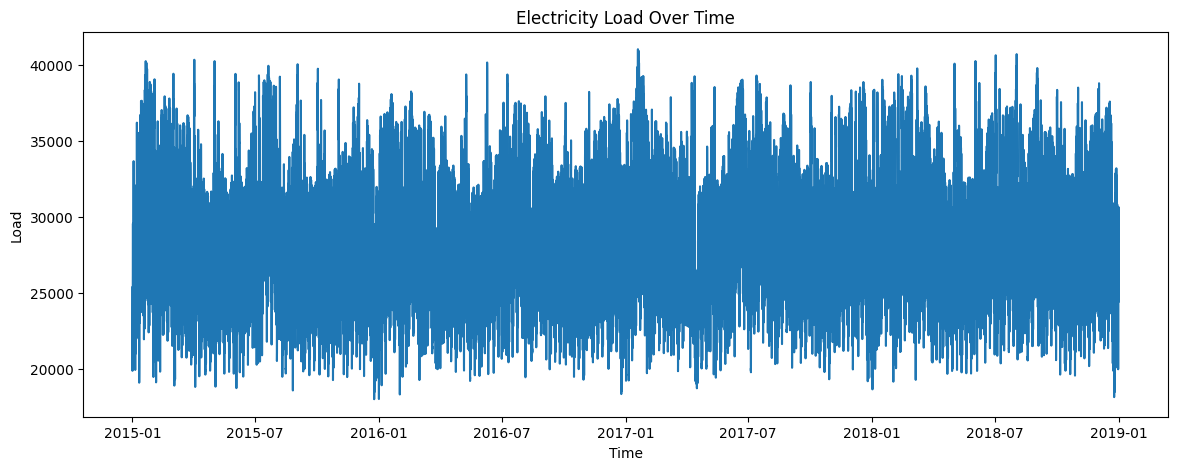

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(df["time"], df["load"])
plt.title("Electricity Load Over Time")
plt.xlabel("Time")
plt.ylabel("Load")
plt.savefig("load_over_time.png", bbox_inches="tight")
plt.show()

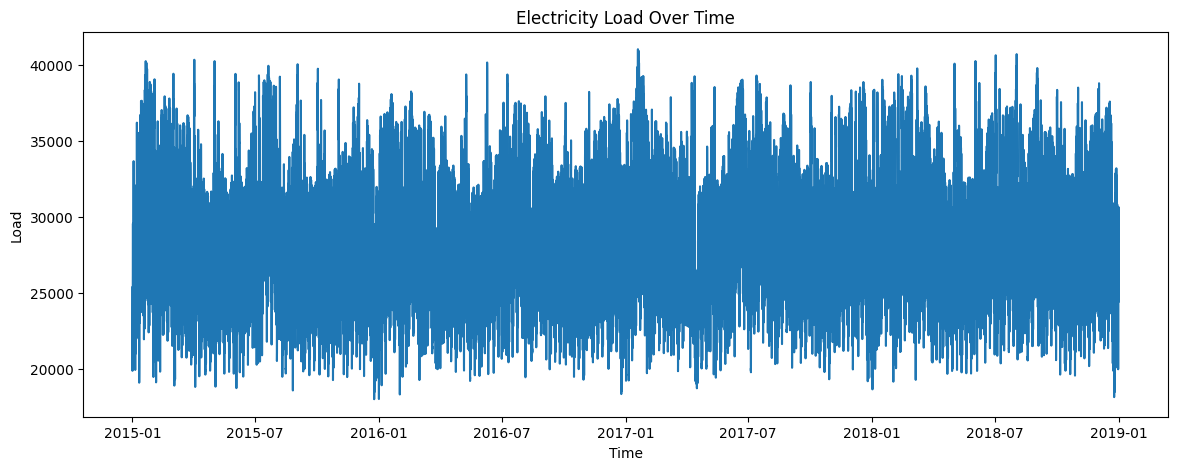

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(df["time"], df["load"])
plt.title("Electricity Load Over Time")
plt.xlabel("Time")
plt.ylabel("Load")
plt.savefig("load_over_time.png", bbox_inches="tight")
plt.show()

In [13]:
df["hour"] = df["time"].dt.hour

In [14]:
df["dayofweek"] = df["time"].dt.dayofweek

In [15]:
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

In [16]:
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

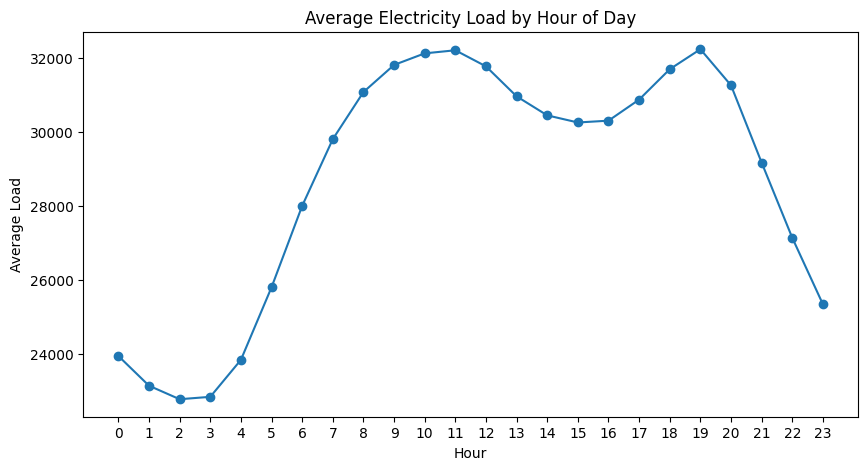

In [18]:
hourly_load = df.groupby("hour")["load"].mean()
plt.figure(figsize=(10, 5))
plt.plot(hourly_load.index, hourly_load.values, marker="o")
plt.title("Average Electricity Load by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Load")
plt.xticks(range(0, 24))
plt.show()

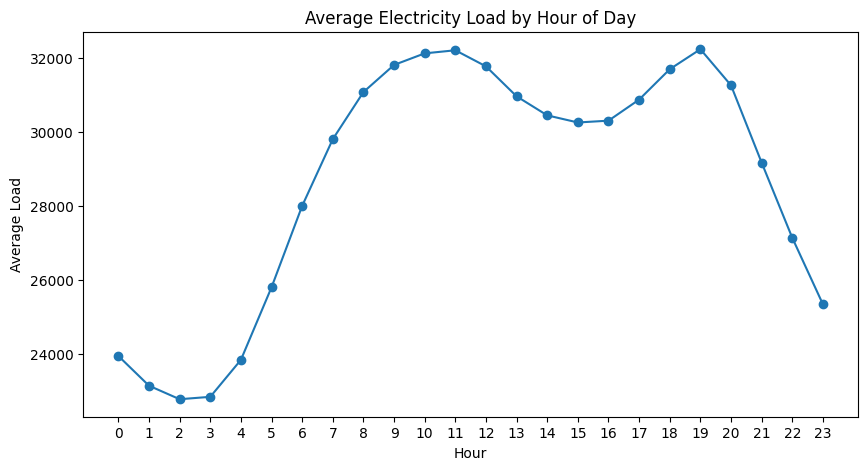

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(hourly_load.index, hourly_load.values, marker="o")
plt.title("Average Electricity Load by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Load")
plt.xticks(range(0, 24))
plt.savefig("avg_load_by_hour.png", bbox_inches="tight")
plt.show()

In [20]:
weekend_load = df.groupby("is_weekend")["load"].mean()

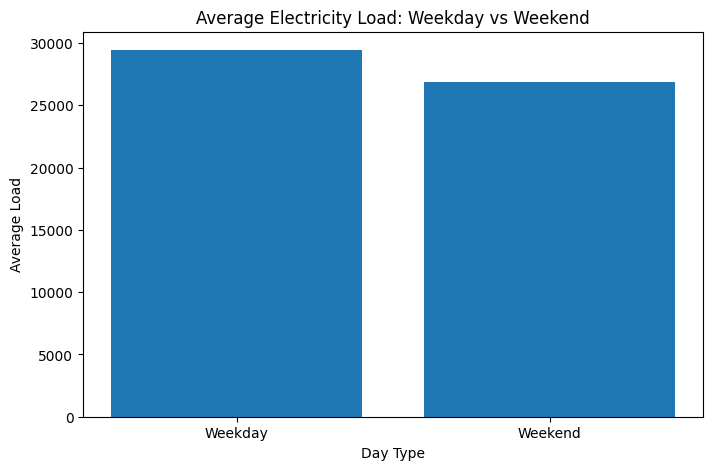

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(["Weekday", "Weekend"], weekend_load.values)
plt.title("Average Electricity Load: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Load")
plt.show()

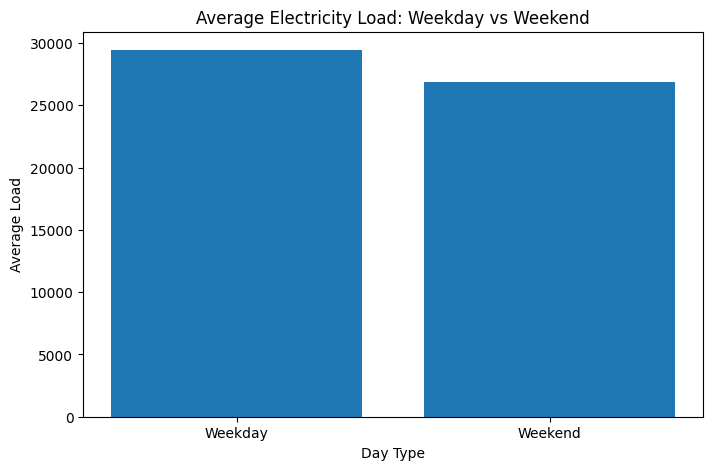

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(["Weekday", "Weekend"], weekend_load.values)
plt.title("Average Electricity Load: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Load")
plt.savefig("weekday_vs_weekend_load.png", bbox_inches="tight")
plt.show()

In [23]:
df["month"] = df["time"].dt.month

In [24]:
monthly_load = df.groupby("month")["load"].mean()

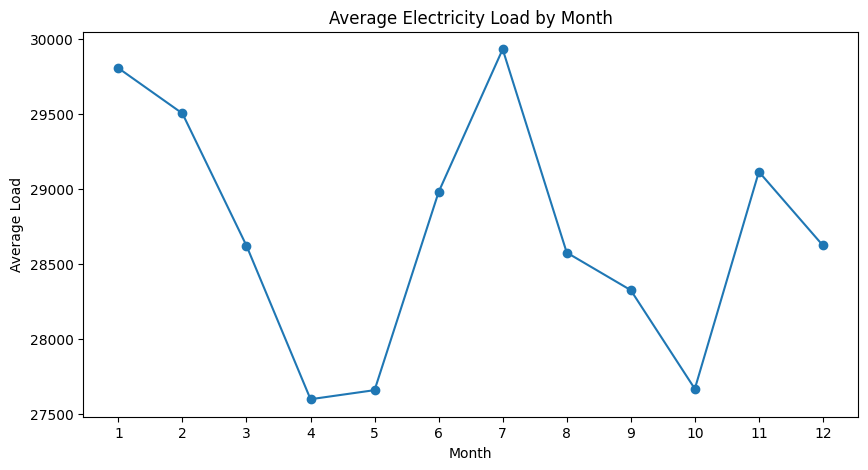

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_load.index, monthly_load.values, marker="o")
plt.title("Average Electricity Load by Month")
plt.xlabel("Month")
plt.ylabel("Average Load")
plt.xticks(range(1, 13))
plt.show()

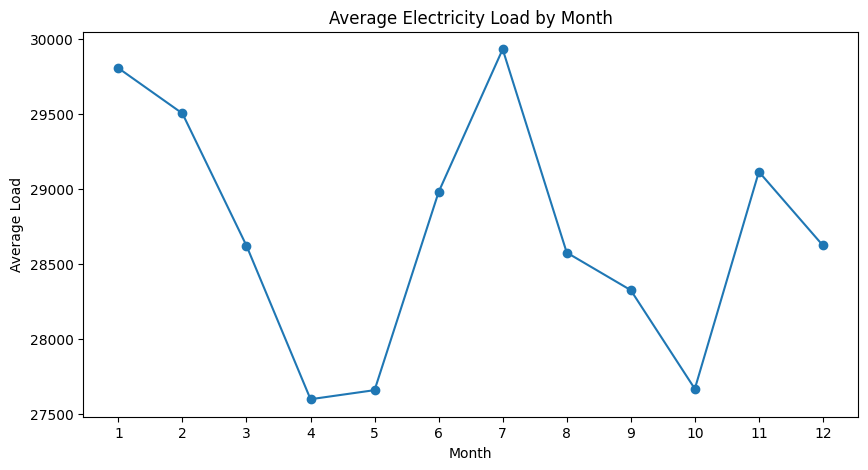

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_load.index, monthly_load.values, marker="o")
plt.title("Average Electricity Load by Month")
plt.xlabel("Month")
plt.ylabel("Average Load")
plt.xticks(range(1, 13))
plt.savefig("avg_load_by_month.png", bbox_inches="tight")
plt.show()

In [28]:
correlation = df[["load", "price"]].corr()
print(correlation)

           load     price
load   1.000000  0.473869
price  0.473869  1.000000


In [29]:
sample_df = df.sample(n=2000, random_state=42)

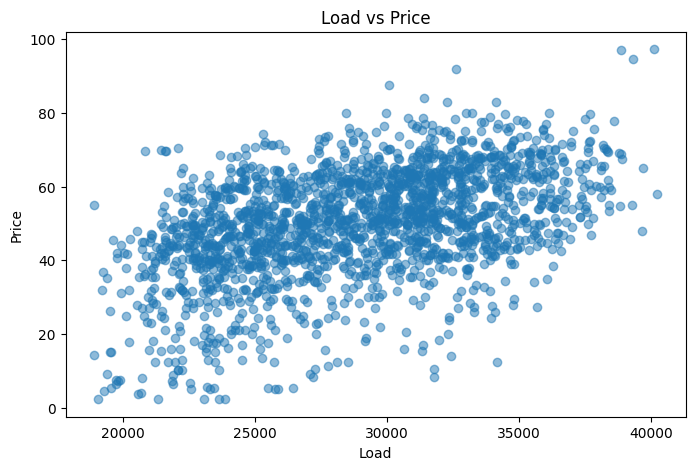

In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(sample_df["load"], sample_df["price"], alpha=0.5)
plt.title("Load vs Price")
plt.xlabel("Load")
plt.ylabel("Price")
plt.show()

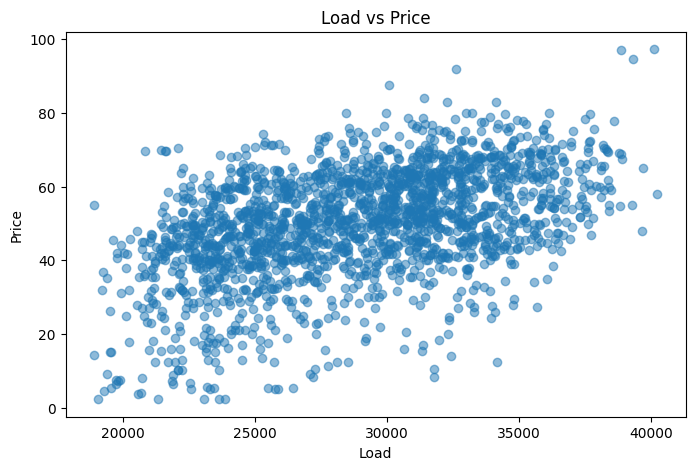

In [31]:
plt.figure(figsize=(8, 5))
plt.scatter(sample_df["load"], sample_df["price"], alpha=0.5)
plt.title("Load vs Price")
plt.xlabel("Load")
plt.ylabel("Price")
plt.savefig("load_vs_price_scatter.png", bbox_inches="tight")
plt.show()

In [32]:
correlation = df[["load", "price"]].corr()
print(correlation)

           load     price
load   1.000000  0.473869
price  0.473869  1.000000
